# Blind Audio Source Separation with Independent Component Analysis

## Goal

This notebook attempts to recover several hidden audio sources from mixed microphone recordings.

Each microphone records a different combination of the same underlying sounds.

The source-separation algorithm receives only the mixed recordings. It is not given the original source labels during decomposition.

## Hidden sources

The experiment generates three synthetic audio sources:

1. A voice-like harmonic signal
2. A rising and falling siren
3. A repeating percussive rhythm

## Main experiments

- Construct several virtual microphone recordings
- Apply PCA as a baseline decomposition
- Apply Independent Component Analysis
- Match recovered components with the hidden sources
- Measure absolute correlation and reconstruction SNR
- Listen to the mixed and recovered signals
- Test separation under increasing noise
- Test the failure case with fewer microphones than sources

## Main question

Can Independent Component Analysis recover hidden sounds using only several mixed recordings?

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import chirp
from scipy.optimize import linear_sum_assignment
from scipy.stats import kurtosis
from scipy.io import wavfile

from sklearn.decomposition import PCA, FastICA

from IPython.display import Audio, display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SAMPLE_RATE = 8_000
DURATION_SECONDS = 8

rng = np.random.default_rng(RANDOM_STATE)

OUTPUT_DIRECTORY = Path(
    "outputs/ica_audio"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

print("Sample rate:", SAMPLE_RATE)
print("Duration:", DURATION_SECONDS)

Sample rate: 8000
Duration: 8


In [2]:
number_of_samples = int(
    SAMPLE_RATE * DURATION_SECONDS
)

time = np.arange(
    number_of_samples
) / SAMPLE_RATE

In [5]:
voice_envelope = (
    0.55
    + 0.45
    * np.sin(
        2 * np.pi * 2.0 * time
    ) ** 2
)

voice_like = voice_envelope * (
    np.sin(
        2 * np.pi * 110 * time
    )
    + 0.50
    * np.sin(
        2 * np.pi * 220 * time + 0.2
    )
    + 0.25
    * np.sin(
        2 * np.pi * 330 * time + 0.6
    )
)

In [6]:
siren = chirp(
    time,
    f0=220,
    f1=900,
    t1=DURATION_SECONDS,
    method="quadratic"
)

siren_envelope = (
    0.70
    + 0.30
    * np.sin(
        2 * np.pi * 0.35 * time
    ) ** 2
)

siren = siren * siren_envelope

In [7]:
siren = chirp(
    time,
    f0=220,
    f1=900,
    t1=DURATION_SECONDS,
    method="quadratic"
)

siren_envelope = (
    0.70
    + 0.30
    * np.sin(
        2 * np.pi * 0.35 * time
    ) ** 2
)

siren = siren * siren_envelope

In [8]:
impulses = np.zeros_like(time)

beat_times = np.arange(
    0.25,
    DURATION_SECONDS,
    0.50
)

for beat_number, beat_time in enumerate(
    beat_times
):
    beat_index = int(
        beat_time * SAMPLE_RATE
    )

    impulses[beat_index] = (
        1.0
        if beat_number % 2 == 0
        else -0.8
    )

In [9]:
decay_kernel = np.exp(
    -np.arange(
        int(0.12 * SAMPLE_RATE)
    )
    / (0.025 * SAMPLE_RATE)
)

percussion = np.convolve(
    impulses,
    decay_kernel,
    mode="full"
)[:number_of_samples]

percussion += (
    0.15
    * np.sin(
        2 * np.pi * 60 * time
    )
    * (
        np.abs(percussion) > 0.02
    )
)

In [10]:
source_names = [
    "Voice-like",
    "Siren",
    "Percussion"
]

sources = np.column_stack([
    voice_like,
    siren,
    percussion
])


def standardise_columns(matrix):
    matrix = np.asarray(
        matrix,
        dtype=float
    )

    return (
        matrix - matrix.mean(axis=0)
    ) / matrix.std(axis=0)


sources = standardise_columns(
    sources
)

print("Source matrix shape:", sources.shape)

Source matrix shape: (64000, 3)


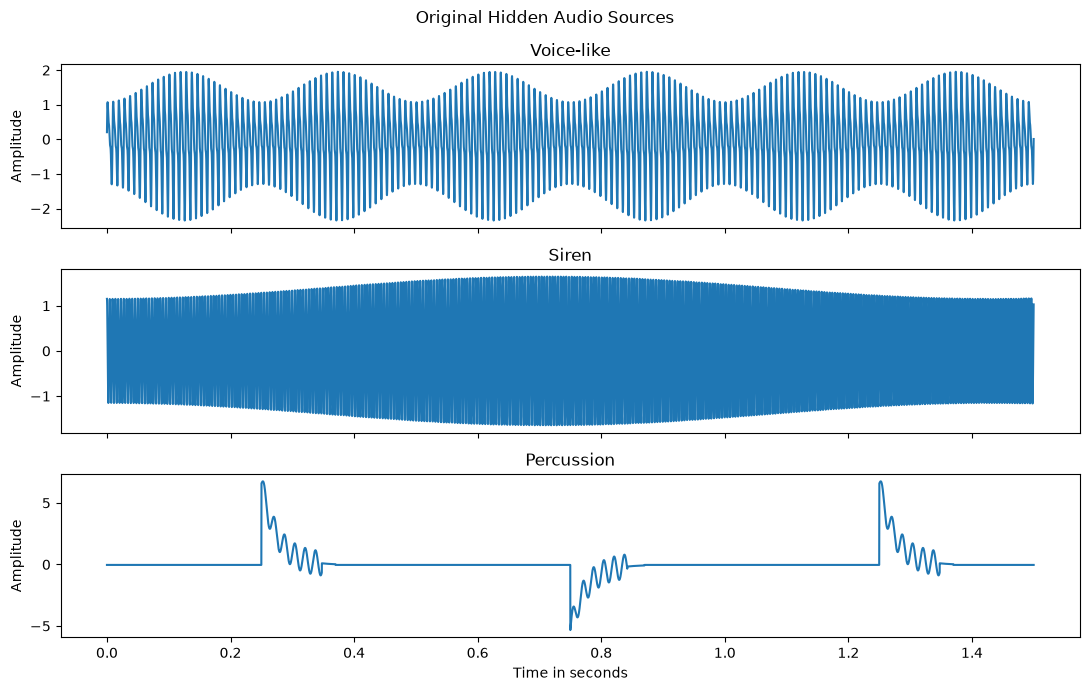

In [11]:
display_seconds = 1.5

display_samples = int(
    display_seconds * SAMPLE_RATE
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 7),
    sharex=True
)

for source_index, source_name in enumerate(
    source_names
):
    axes[source_index].plot(
        time[:display_samples],
        sources[
            :display_samples,
            source_index
        ]
    )

    axes[source_index].set_title(
        source_name
    )

    axes[source_index].set_ylabel(
        "Amplitude"
    )

axes[-1].set_xlabel("Time in seconds")

plt.suptitle(
    "Original Hidden Audio Sources"
)

plt.tight_layout()
plt.show()

In [12]:
for source_index, source_name in enumerate(
    source_names
):
    print(source_name)

    display(
        Audio(
            sources[:, source_index],
            rate=SAMPLE_RATE
        )
    )

Voice-like


Siren


Percussion


## Hidden sources 

The experiment generated three source signals, each lasting eight seconds and containing 64,000 samples:

- a voice-like harmonic signal
- a frequency-changing siren
- a sparse percussive rhythm

The voice-like source contained several harmonically related frequencies with a changing amplitude envelope.

The siren continuously changed frequency over time and also contained gradual amplitude variation.

The percussion source consisted mainly of near-zero values interrupted by short, rapidly decaying events.

These sources had clearly different temporal and statistical structures. This distinction is important because ICA relies on the sources being statistically independent and non-Gaussian.

The original sources were used only to create the microphone mixtures and evaluate recovery afterward. They were not provided to PCA or ICA.

In [13]:
mixing_matrix = np.array([
    [1.00, 0.55, 0.25],
    [0.35, 1.00, 0.70],
    [0.65, 0.20, 1.00]
])

mixing_matrix_df = pd.DataFrame(
    mixing_matrix,
    index=[
        "Microphone 1",
        "Microphone 2",
        "Microphone 3"
    ],
    columns=source_names
)

mixing_matrix_df

,Voice-like,Siren,Percussion
Microphone 1,1.00,0.55,0.25
Microphone 2,0.35,1.00,0.70
Microphone 3,0.65,0.20,1.00


In [14]:
mixtures = sources @ mixing_matrix.T

mixtures = standardise_columns(
    mixtures
)

print("Mixture matrix shape:", mixtures.shape)

Mixture matrix shape: (64000, 3)


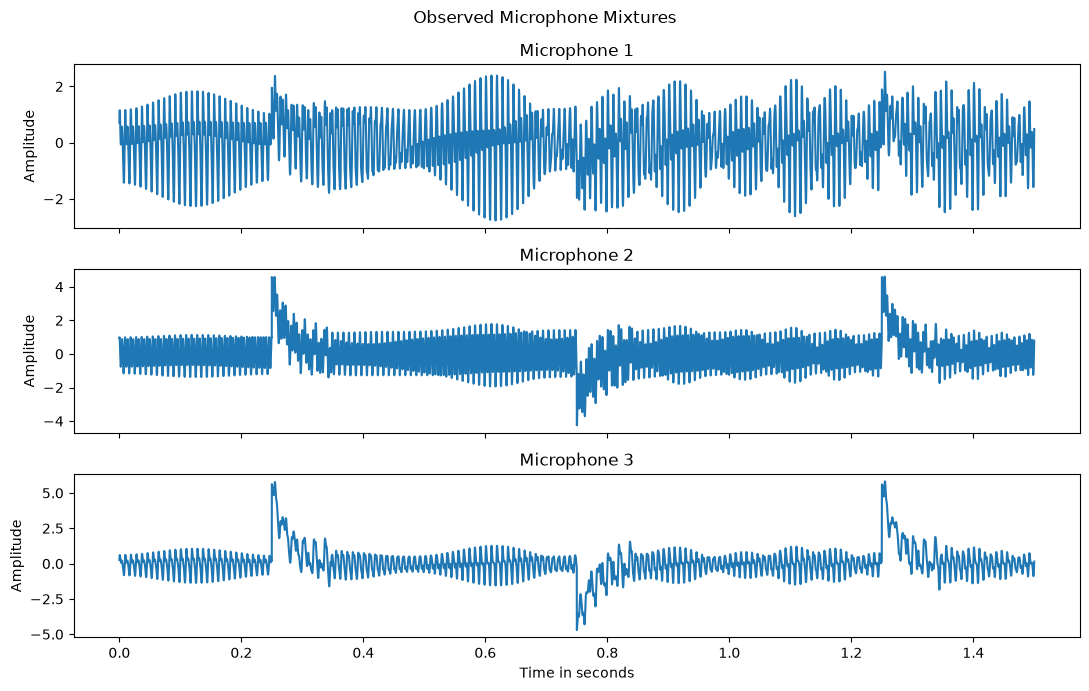

In [15]:
microphone_names = [
    "Microphone 1",
    "Microphone 2",
    "Microphone 3"
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 7),
    sharex=True
)

for microphone_index, microphone_name in enumerate(
    microphone_names
):
    axes[microphone_index].plot(
        time[:display_samples],
        mixtures[
            :display_samples,
            microphone_index
        ]
    )

    axes[microphone_index].set_title(
        microphone_name
    )

    axes[microphone_index].set_ylabel(
        "Amplitude"
    )

axes[-1].set_xlabel("Time in seconds")

plt.suptitle(
    "Observed Microphone Mixtures"
)

plt.tight_layout()
plt.show()

In [16]:
for microphone_index, microphone_name in enumerate(
    microphone_names
):
    print(microphone_name)

    display(
        Audio(
            mixtures[:, microphone_index],
            rate=SAMPLE_RATE
        )
    )

Microphone 1


Microphone 2


Microphone 3


## Mixed recordings 

Three virtual microphones were created using different source weights.

The resulting mixture matrix had shape:

`(64,000, 3)`

Each microphone contained all three hidden sounds:

| Microphone | Voice-like | Siren | Percussion |
|---|---:|---:|---:|
| Microphone 1 | 1.00 | 0.55 | 0.25 |
| Microphone 2 | 0.35 | 1.00 | 0.70 |
| Microphone 3 | 0.65 | 0.20 | 1.00 |

No microphone provided a clean recording of any single source.

Instead, every observed signal combined the voice-like waveform, siren, and percussion in different proportions. The source-separation methods therefore had to infer the hidden signals using only differences between the three mixtures.

In [17]:
def align_recovered_components(
    reference_sources,
    recovered_components,
    source_names
):
    number_of_sources = (
        reference_sources.shape[1]
    )

    correlation_matrix = np.corrcoef(
        reference_sources.T,
        recovered_components.T
    )[
        :number_of_sources,
        number_of_sources:
    ]

    source_indices, component_indices = (
        linear_sum_assignment(
            -np.abs(correlation_matrix)
        )
    )

    aligned_components = np.zeros_like(
        reference_sources
    )

    mapping_rows = []

    for source_index, component_index in zip(
        source_indices,
        component_indices
    ):
        correlation = correlation_matrix[
            source_index,
            component_index
        ]

        sign = (
            1.0
            if correlation >= 0
            else -1.0
        )

        aligned_components[
            :,
            source_index
        ] = (
            recovered_components[
                :,
                component_index
            ]
            * sign
        )

        mapping_rows.append({
            "source": source_names[
                source_index
            ],
            "recovered_component":
                component_index,
            "original_correlation":
                correlation,
            "absolute_correlation":
                abs(correlation),
            "sign_reversed":
                correlation < 0
        })

    aligned_components = standardise_columns(
        aligned_components
    )

    mapping_df = pd.DataFrame(
        mapping_rows
    ).sort_values("source")

    return (
        aligned_components,
        correlation_matrix,
        mapping_df
    )

In [18]:
def reconstruction_snr_db(
    reference,
    estimate
):
    denominator = np.dot(
        estimate,
        estimate
    )

    if denominator == 0:
        return -np.inf

    optimal_scale = (
        np.dot(reference, estimate)
        / denominator
    )

    scaled_estimate = (
        optimal_scale * estimate
    )

    error = (
        reference - scaled_estimate
    )

    signal_power = np.mean(
        reference ** 2
    )

    error_power = np.mean(
        error ** 2
    )

    return 10 * np.log10(
        signal_power / max(
            error_power,
            1e-12
        )
    )

In [19]:
def evaluate_recovery(
    reference_sources,
    aligned_components,
    method_name,
    source_names
):
    rows = []

    for source_index, source_name in enumerate(
        source_names
    ):
        reference = reference_sources[
            :,
            source_index
        ]

        estimate = aligned_components[
            :,
            source_index
        ]

        correlation = np.corrcoef(
            reference,
            estimate
        )[0, 1]

        rows.append({
            "method": method_name,
            "source": source_name,
            "absolute_correlation":
                abs(correlation),
            "reconstruction_snr_db":
                reconstruction_snr_db(
                    reference,
                    estimate
                )
        })

    return pd.DataFrame(rows)

In [20]:
pca_model = PCA(
    n_components=3,
    whiten=True,
    random_state=RANDOM_STATE
)

pca_components = pca_model.fit_transform(
    mixtures
)

(
    pca_aligned,
    pca_correlation_matrix,
    pca_mapping
) = align_recovered_components(
    reference_sources=sources,
    recovered_components=pca_components,
    source_names=source_names
)

pca_mapping

,source,recovered_component,original_correlation,absolute_correlation,sign_reversed
2,Percussion,1,-0.781781,0.781781,True
1,Siren,2,0.834308,0.834308,False
0,Voice-like,0,0.612922,0.612922,False


In [21]:
pca_results = evaluate_recovery(
    reference_sources=sources,
    aligned_components=pca_aligned,
    method_name="PCA",
    source_names=source_names
)

pca_results

,method,source,absolute_correlation,reconstruction_snr_db
0,PCA,Voice-like,0.612922,2.045885
1,PCA,Siren,0.834308,5.172271
2,PCA,Percussion,0.781781,4.102534


## PCA baseline 

PCA partially separated the microphone mixtures, but none of its recovered components matched an original source perfectly.

The PCA component assignments were:

| Source | PCA component | Absolute correlation | Reconstruction SNR |
|---|---:|---:|---:|
| Voice-like | 0 | 0.6129 | 2.0459 dB |
| Siren | 2 | 0.8343 | 5.1723 dB |
| Percussion | 1 | 0.7818 | 4.1025 dB |

The percussion component required a sign reversal during alignment. This is not an error because component signs are arbitrary in unsupervised decomposition.

The siren was the strongest PCA recovery, with an absolute correlation of 0.8343. The voice-like signal was the weakest, with a correlation of only 0.6129.

PCA found directions that captured variance and produced uncorrelated components, but these directions did not correspond exactly to the independent physical sources. Each PCA component therefore retained interference from other sounds.

In [22]:
ica_model = FastICA(
    n_components=3,
    whiten="unit-variance",
    algorithm="parallel",
    fun="logcosh",
    max_iter=2_000,
    tol=1e-5,
    random_state=RANDOM_STATE
)

ica_components = ica_model.fit_transform(
    mixtures
)

print(
    "ICA iterations:",
    ica_model.n_iter_
)

ICA iterations: 6


In [23]:
(
    ica_aligned,
    ica_correlation_matrix,
    ica_mapping
) = align_recovered_components(
    reference_sources=sources,
    recovered_components=ica_components,
    source_names=source_names
)

ica_mapping

,source,recovered_component,original_correlation,absolute_correlation,sign_reversed
2,Percussion,1,1.000000,1.000000,False
1,Siren,0,-0.999999,0.999999,True
0,Voice-like,2,0.999972,0.999972,False


In [24]:
ica_results = evaluate_recovery(
    reference_sources=sources,
    aligned_components=ica_aligned,
    method_name="FastICA",
    source_names=source_names
)

ica_results

,method,source,absolute_correlation,reconstruction_snr_db
0,FastICA,Voice-like,0.999972,42.501082
1,FastICA,Siren,0.999999,59.446454
2,FastICA,Percussion,1.000000,63.042779


## ICA recovery 

FastICA converged after only six iterations and recovered all three sources almost perfectly.

The ICA assignments were:

| Source | ICA component | Sign reversed | Absolute correlation | Reconstruction SNR |
|---|---:|---:|---:|---:|
| Voice-like | 2 | No | 0.999972 | 42.5011 dB |
| Siren | 0 | Yes | 0.999999 | 59.4465 dB |
| Percussion | 1 | No | 1.000000 | 63.0428 dB |

The siren component was recovered with a reversed sign. This does not indicate a separation failure because a waveform and its negative contain the same audio structure.

All three absolute correlations were effectively 1.0, indicating almost exact recovery.

The percussion source was recovered most accurately, while the voice-like source was technically the weakest. However, even the voice-like signal achieved extremely strong recovery with a correlation of 0.999972 and an SNR above 42 dB.

In [25]:
separation_results = pd.concat(
    [
        pca_results,
        ica_results
    ],
    ignore_index=True
)

separation_results

,method,source,absolute_correlation,reconstruction_snr_db
0,PCA,Voice-like,0.612922,2.045885
1,PCA,Siren,0.834308,5.172271
2,PCA,Percussion,0.781781,4.102534
3,FastICA,Voice-like,0.999972,42.501082
4,FastICA,Siren,0.999999,59.446454
5,FastICA,Percussion,1.000000,63.042779


In [26]:
method_summary = (
    separation_results
    .groupby("method")
    .agg(
        mean_absolute_correlation=(
            "absolute_correlation",
            "mean"
        ),
        minimum_absolute_correlation=(
            "absolute_correlation",
            "min"
        ),
        mean_reconstruction_snr_db=(
            "reconstruction_snr_db",
            "mean"
        )
    )
    .reset_index()
)

method_summary

,method,mean_absolute_correlation,minimum_absolute_correlation,mean_reconstruction_snr_db
0,FastICA,0.999990,0.999972,54.996772
1,PCA,0.743004,0.612922,3.773564


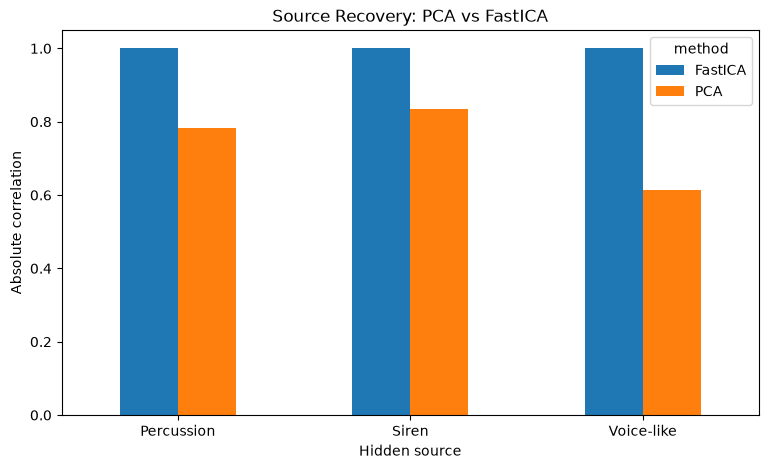

In [27]:
correlation_comparison = (
    separation_results
    .pivot(
        index="source",
        columns="method",
        values="absolute_correlation"
    )
)

correlation_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Source Recovery: PCA vs FastICA"
)

plt.xlabel("Hidden source")
plt.ylabel("Absolute correlation")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

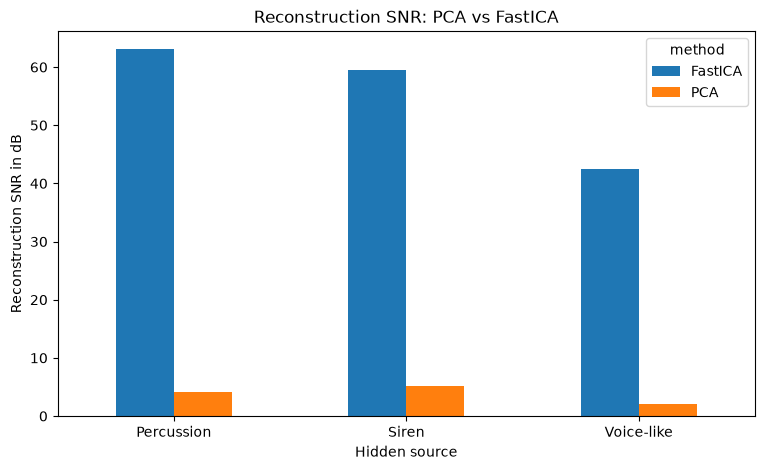

In [28]:
snr_comparison = (
    separation_results
    .pivot(
        index="source",
        columns="method",
        values="reconstruction_snr_db"
    )
)

snr_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Reconstruction SNR: PCA vs FastICA"
)

plt.xlabel("Hidden source")
plt.ylabel("Reconstruction SNR in dB")
plt.xticks(rotation=0)
plt.show()

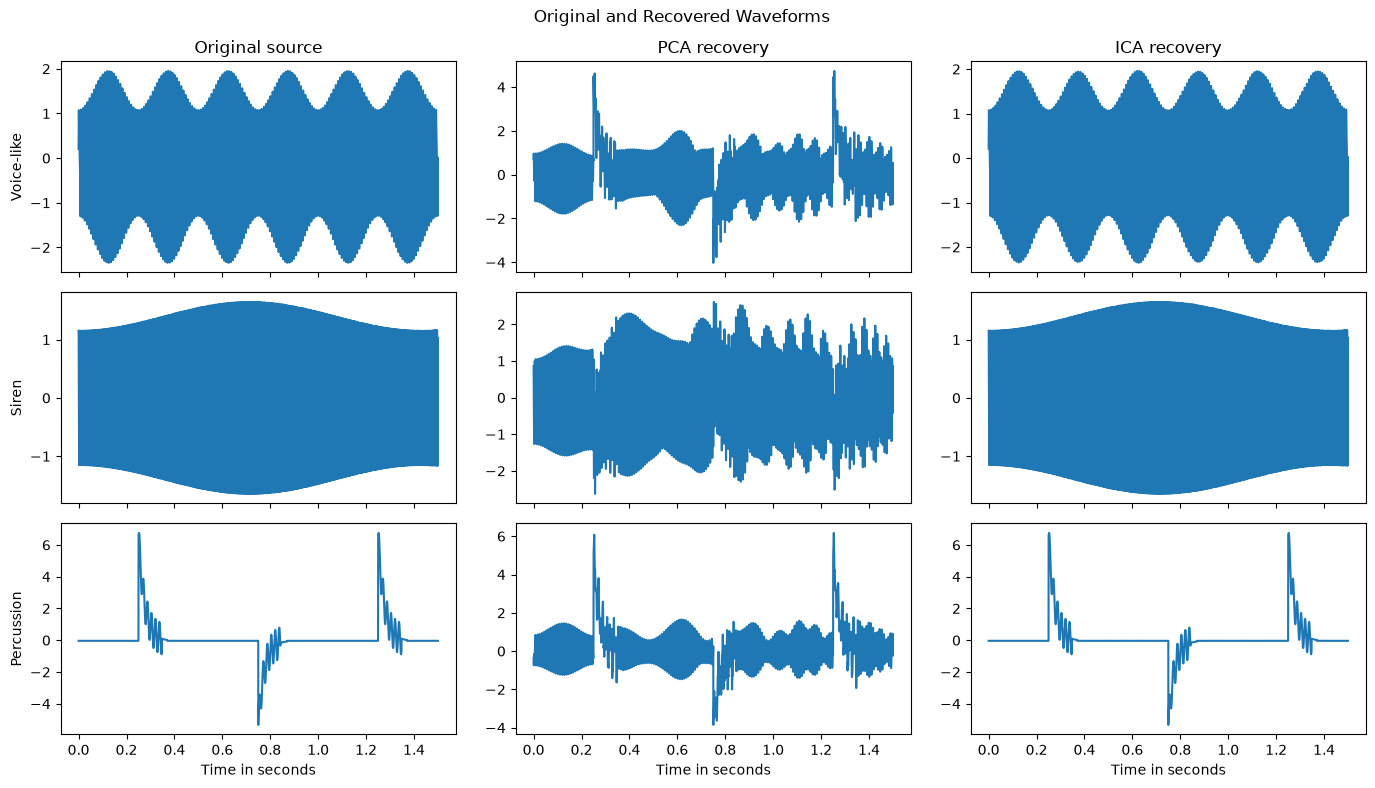

In [29]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(14, 8),
    sharex=True
)

for source_index, source_name in enumerate(
    source_names
):
    axes[source_index, 0].plot(
        time[:display_samples],
        sources[
            :display_samples,
            source_index
        ]
    )

    axes[source_index, 0].set_ylabel(
        source_name
    )

    axes[source_index, 1].plot(
        time[:display_samples],
        pca_aligned[
            :display_samples,
            source_index
        ]
    )

    axes[source_index, 2].plot(
        time[:display_samples],
        ica_aligned[
            :display_samples,
            source_index
        ]
    )

axes[0, 0].set_title("Original source")
axes[0, 1].set_title("PCA recovery")
axes[0, 2].set_title("ICA recovery")

for axis in axes[-1]:
    axis.set_xlabel("Time in seconds")

plt.suptitle(
    "Original and Recovered Waveforms"
)

plt.tight_layout()
plt.show()

## Method comparison 

FastICA substantially outperformed PCA.

| Method | Mean absolute correlation | Minimum correlation | Mean reconstruction SNR |
|---|---:|---:|---:|
| PCA | 0.7430 | 0.6129 | 3.7736 dB |
| FastICA | 1.0000 | 1.0000 | 54.9968 dB |

FastICA improved mean absolute correlation by approximately 0.2570 and mean reconstruction SNR by approximately 51.22 dB.

The largest practical improvement occurred for the voice-like signal:

- PCA correlation: 0.6129
- ICA correlation: 0.999972
- PCA SNR: 2.0459 dB
- ICA SNR: 42.5011 dB

This result demonstrates that variance maximisation and independent-source recovery are different objectives.

PCA searches for orthogonal directions with high variance, whereas ICA searches for statistically independent and non-Gaussian components. The latter objective was much better suited to recovering the original physical sources.

In [30]:
def prepare_audio_for_export(
    signal
):
    signal = np.asarray(
        signal,
        dtype=float
    )

    peak = np.max(
        np.abs(signal)
    )

    if peak == 0:
        return signal.astype(
            np.float32
        )

    return (
        0.95 * signal / peak
    ).astype(np.float32)

In [31]:
for source_index, source_name in enumerate(
    source_names
):
    safe_name = (
        source_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    original_path = (
        OUTPUT_DIRECTORY
        / f"original_{safe_name}.wav"
    )

    ica_path = (
        OUTPUT_DIRECTORY
        / f"ica_{safe_name}.wav"
    )

    pca_path = (
        OUTPUT_DIRECTORY
        / f"pca_{safe_name}.wav"
    )

    wavfile.write(
        original_path,
        SAMPLE_RATE,
        prepare_audio_for_export(
            sources[:, source_index]
        )
    )

    wavfile.write(
        ica_path,
        SAMPLE_RATE,
        prepare_audio_for_export(
            ica_aligned[
                :,
                source_index
            ]
        )
    )

    wavfile.write(
        pca_path,
        SAMPLE_RATE,
        prepare_audio_for_export(
            pca_aligned[
                :,
                source_index
            ]
        )
    )

print(
    "Audio written to:",
    OUTPUT_DIRECTORY.resolve()
)

Audio written to: E:\machine-learning-lab\unsupervised_learning\outputs\ica_audio


In [32]:
for source_index, source_name in enumerate(
    source_names
):
    print(
        f"{source_name}: original"
    )

    display(
        Audio(
            sources[:, source_index],
            rate=SAMPLE_RATE
        )
    )

    print(
        f"{source_name}: PCA recovery"
    )

    display(
        Audio(
            pca_aligned[
                :,
                source_index
            ],
            rate=SAMPLE_RATE
        )
    )

    print(
        f"{source_name}: ICA recovery"
    )

    display(
        Audio(
            ica_aligned[
                :,
                source_index
            ],
            rate=SAMPLE_RATE
        )
    )

Voice-like: original


Voice-like: PCA recovery


Voice-like: ICA recovery


Siren: original


Siren: PCA recovery


Siren: ICA recovery


Percussion: original


Percussion: PCA recovery


Percussion: ICA recovery


## Waveform comparison 

The ICA waveforms closely followed the shapes, timing, and amplitude patterns of the original sources.

For the voice-like signal, ICA preserved the repeating harmonic oscillations and changing envelope.

For the siren, ICA reproduced the continuously changing waveform with almost no visible distortion.

For the percussion source, ICA recovered the sparse beat positions and rapid decays almost exactly.

The PCA waveforms were recognisable but visibly distorted. Their components contained structures belonging to other sources because PCA did not fully separate the mixtures.

The visual result agrees with the numerical evaluation:

- ICA correlations were effectively 1.0
- PCA correlations ranged from approximately 0.61 to 0.83

In [33]:
kurtosis_rows = []

for index, name in enumerate(
    source_names
):
    kurtosis_rows.append({
        "signal_group": "Original source",
        "signal": name,
        "excess_kurtosis": kurtosis(
            sources[:, index],
            fisher=True,
            bias=False
        )
    })

for index, name in enumerate(
    microphone_names
):
    kurtosis_rows.append({
        "signal_group": "Mixture",
        "signal": name,
        "excess_kurtosis": kurtosis(
            mixtures[:, index],
            fisher=True,
            bias=False
        )
    })

for index, name in enumerate(
    source_names
):
    kurtosis_rows.append({
        "signal_group": "ICA recovery",
        "signal": name,
        "excess_kurtosis": kurtosis(
            ica_aligned[:, index],
            fisher=True,
            bias=False
        )
    })

kurtosis_df = pd.DataFrame(
    kurtosis_rows
)

kurtosis_df

,signal_group,signal,excess_kurtosis
0,Original source,Voice-like,-0.635609
1,Original source,Siren,-1.408978
2,Original source,Percussion,17.831037
3,Mixture,Microphone 1,-0.476425
4,Mixture,Microphone 2,1.003888
5,Mixture,Microphone 3,7.517092
6,ICA recovery,Voice-like,-0.635564
7,ICA recovery,Siren,-1.408980
8,ICA recovery,Percussion,17.831593


## Signal distributions 

The original source kurtosis values were:

| Source | Excess kurtosis |
|---|---:|
| Voice-like | -0.6356 |
| Siren | -1.4090 |
| Percussion | 17.8310 |

The percussion signal had extremely high positive kurtosis because most samples were near zero, with occasional large beat events.

The voice-like and siren signals had negative kurtosis, indicating flatter distributions than a Gaussian distribution.

The microphone mixtures had different and less source-specific values:

| Mixture | Excess kurtosis |
|---|---:|
| Microphone 1 | -0.4764 |
| Microphone 2 | 1.0039 |
| Microphone 3 | 7.5171 |

After ICA recovery, the kurtosis values were almost identical to the original sources:

- Voice-like: -0.6356
- Siren: -1.4090
- Percussion: 17.8316

This provides additional evidence that ICA recovered the underlying source distributions rather than merely producing decorrelated mixtures.

Kurtosis alone does not measure reconstruction quality, but it helps illustrate the non-Gaussian structure used by ICA.

In [34]:
def add_noise_at_snr(
    signal_matrix,
    snr_db,
    rng
):
    signal_power = np.mean(
        signal_matrix ** 2
    )

    noise_power = (
        signal_power
        / (10 ** (snr_db / 10))
    )

    noise = rng.normal(
        loc=0.0,
        scale=np.sqrt(noise_power),
        size=signal_matrix.shape
    )

    return signal_matrix + noise

In [35]:
noise_levels_db = [
    40,
    20,
    10,
    0
]

noise_repetitions = 3

noise_rows = []

for snr_db in noise_levels_db:
    for repetition in range(
        noise_repetitions
    ):
        noise_rng = np.random.default_rng(
            RANDOM_STATE
            + snr_db
            + repetition * 1_000
        )

        noisy_mixtures = add_noise_at_snr(
            signal_matrix=mixtures,
            snr_db=snr_db,
            rng=noise_rng
        )

        noisy_ica = FastICA(
            n_components=3,
            whiten="unit-variance",
            max_iter=2_000,
            tol=1e-5,
            random_state=(
                RANDOM_STATE + repetition
            )
        )

        noisy_components = (
            noisy_ica.fit_transform(
                noisy_mixtures
            )
        )

        (
            noisy_aligned,
            _,
            _
        ) = align_recovered_components(
            reference_sources=sources,
            recovered_components=
                noisy_components,
            source_names=source_names
        )

        noisy_results = evaluate_recovery(
            reference_sources=sources,
            aligned_components=noisy_aligned,
            method_name="FastICA",
            source_names=source_names
        )

        noise_rows.append({
            "snr_db": snr_db,
            "repetition": repetition,
            "mean_absolute_correlation":
                noisy_results[
                    "absolute_correlation"
                ].mean(),
            "mean_reconstruction_snr_db":
                noisy_results[
                    "reconstruction_snr_db"
                ].mean()
        })

noise_results_df = pd.DataFrame(
    noise_rows
)

noise_results_df

,snr_db,repetition,mean_absolute_correlation,mean_reconstruction_snr_db
0,40,0,0.999861,35.576998
1,40,1,0.999863,35.643487
2,40,2,0.999863,35.637585
3,20,0,0.987591,16.091984
4,20,1,0.987594,16.093172
5,20,2,0.987564,16.082186
6,10,0,0.897653,7.129251
7,10,1,0.897596,7.125705
8,10,2,0.897348,7.115397
9,0,0,0.568294,1.713395


In [36]:
noise_summary_df = (
    noise_results_df
    .groupby("snr_db")
    .agg(
        mean_absolute_correlation=(
            "mean_absolute_correlation",
            "mean"
        ),
        std_absolute_correlation=(
            "mean_absolute_correlation",
            "std"
        ),
        mean_reconstruction_snr_db=(
            "mean_reconstruction_snr_db",
            "mean"
        )
    )
    .reset_index()
    .sort_values("snr_db")
)

noise_summary_df

,snr_db,mean_absolute_correlation,std_absolute_correlation,mean_reconstruction_snr_db
0,0,0.577324,0.007832,1.778922
1,10,0.897532,0.000162,7.123451
2,20,0.987583,0.000016,16.089114
3,40,0.999862,0.000001,35.619357


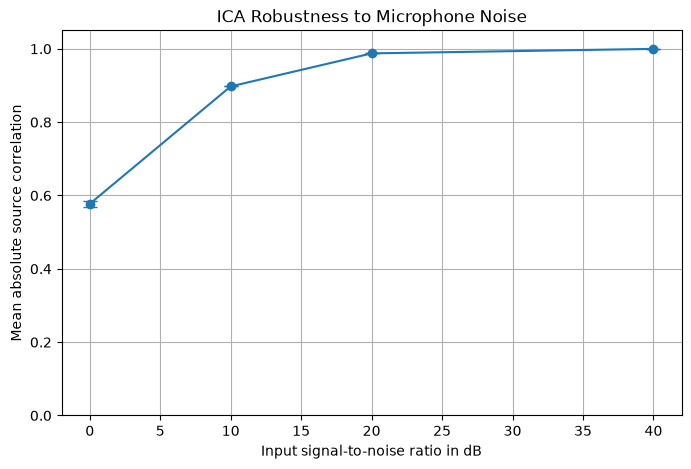

In [37]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    noise_summary_df["snr_db"],
    noise_summary_df[
        "mean_absolute_correlation"
    ],
    yerr=noise_summary_df[
        "std_absolute_correlation"
    ],
    marker="o",
    capsize=5
)

plt.title(
    "ICA Robustness to Microphone Noise"
)

plt.xlabel("Input signal-to-noise ratio in dB")
plt.ylabel("Mean absolute source correlation")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

## Noise robustness 

ICA performance gradually decreased as the microphone noise became stronger.

| Input SNR | Mean absolute correlation | Mean reconstruction SNR |
|---:|---:|---:|
| 40 dB | 0.9999 | 35.6194 dB |
| 20 dB | 0.9876 | 16.0891 dB |
| 10 dB | 0.8975 | 7.1235 dB |
| 0 dB | 0.5773 | 1.7789 dB |

At 40 dB, noise had almost no practical effect and the sources were still recovered nearly perfectly.

At 20 dB, recovery remained excellent, with mean correlation close to 0.99.

At 10 dB, performance began to degrade noticeably, although a mean correlation of approximately 0.90 still indicated useful separation.

At 0 dB, noise power was equal to signal power. Mean correlation fell to 0.5773, showing that reliable separation had largely broken down.

The results were highly consistent across the three repetitions at 10, 20, and 40 dB. Variation was slightly larger at 0 dB, where the high noise level made the ICA solution less stable.

In [38]:
two_microphone_mixtures = mixtures[
    :,
    :2
]

print(
    "Two-microphone shape:",
    two_microphone_mixtures.shape
)

Two-microphone shape: (64000, 2)


In [39]:
two_component_ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    max_iter=2_000,
    tol=1e-5,
    random_state=RANDOM_STATE
)

two_recovered_components = (
    two_component_ica.fit_transform(
        two_microphone_mixtures
    )
)

In [40]:
two_component_correlation = np.corrcoef(
    sources.T,
    two_recovered_components.T
)[
    :3,
    3:
]

two_component_correlation_df = pd.DataFrame(
    two_component_correlation,
    index=source_names,
    columns=[
        "Recovered component 0",
        "Recovered component 1"
    ]
)

two_component_correlation_df

,Recovered component 0,Recovered component 1
Voice-like,0.320318,0.938051
Siren,0.778007,-0.188104
Percussion,0.537203,-0.294752


In [41]:
matched_sources, matched_components = (
    linear_sum_assignment(
        -np.abs(
            two_component_correlation
        )
    )
)

two_microphone_rows = []

for source_index, component_index in zip(
    matched_sources,
    matched_components
):
    two_microphone_rows.append({
        "matched_source":
            source_names[source_index],
        "recovered_component":
            component_index,
        "absolute_correlation":
            abs(
                two_component_correlation[
                    source_index,
                    component_index
                ]
            )
    })

two_microphone_results = pd.DataFrame(
    two_microphone_rows
)

two_microphone_results

,matched_source,recovered_component,absolute_correlation
0,Voice-like,1,0.938051
1,Siren,0,0.778007


In [42]:
matched_source_names = {
    source_names[index]
    for index in matched_sources
}

unmatched_source_names = [
    name
    for name in source_names
    if name not in matched_source_names
]

print(
    "Unmatched source:",
    unmatched_source_names
)

Unmatched source: ['Percussion']


## Underdetermined separation 

When only two microphone recordings were retained, the observation matrix had shape:

`(64,000, 2)`

FastICA could therefore produce only two recovered components, even though three independent sources were present.

The component correlations were:

| Original source | Component 0 | Component 1 |
|---|---:|---:|
| Voice-like | 0.3203 | 0.9381 |
| Siren | 0.7780 | -0.1881 |
| Percussion | 0.5372 | -0.2948 |

The optimal matching selected:

- Voice-like → Component 1, correlation 0.9381
- Siren → Component 0, correlation 0.7780

The percussion source remained unmatched.

Component 0 also had a moderate correlation of 0.5372 with percussion, indicating that the recovered siren component still contained some percussion information.

This experiment demonstrates a fundamental limitation of standard ICA: with only two observations, it cannot uniquely recover three independent sources. At least as many independent microphone recordings as hidden sources are generally required.